# Real-World Data Project — Finance: Loan Default Risk

**Goal:** Work on a domain-specific dataset for applied learning — choose a dataset, perform
end-to-end data analysis/prediction, and present findings with visualizations and conclusions.

**Domain:** Finance — predicting loan default risk for a lending business.

This notebook covers the full applied workflow:
1. Load raw applicant data
2. Clean the data
3. Exploratory analysis of default risk factors
4. Build and evaluate predictive models
5. Present findings and business recommendations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, roc_curve, auc, classification_report)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

## 1. Load Raw Data

In [2]:
df_raw = pd.read_csv("../data/raw_loan_data.csv")
print(df_raw.shape)
df_raw.head()

(2020, 13)


,ApplicantID,Age,AnnualIncome,EmploymentType,CreditScore,LoanAmount,LoanTermMonths,NumExistingLoans,HomeOwnership,MaritalStatus,LoanPurpose,DebtToIncomeRatio,LoanDefault
0,LN5000,59,93421.64,Salaried,642.0,12767.96,60,0,Mortgage,Single,Business,0.125,0
1,LN5001,49,43014.82,Salaried,793.0,24356.64,24,1,Rent,Single,Education,0.494,0
2,LN5002,35,52065.09,Salaried,687.0,15275.13,48,1,Mortgage,Married,Medical,0.327,0
3,LN5003,63,29309.38,Self-Employed,563.0,24102.94,48,0,Mortgage,Divorced,Medical,0.843,1
4,LN5004,28,25873.87,Business Owner,662.0,24846.35,12,2,Mortgage,Married,Medical,0.849,0


In [3]:
print("Missing values:\n", df_raw.isna().sum())
print("\nDuplicate ApplicantIDs:", df_raw['ApplicantID'].duplicated().sum())
print("\nDefault rate:", df_raw['LoanDefault'].mean().round(3))

Missing values:
 ApplicantID           0
Age                   0
AnnualIncome         25
EmploymentType        0
CreditScore          40
LoanAmount            0
LoanTermMonths        0
NumExistingLoans      0
HomeOwnership         0
MaritalStatus         0
LoanPurpose           0
DebtToIncomeRatio     0
LoanDefault           0
dtype: int64

Duplicate ApplicantIDs: 20

Default rate: 0.194


## 2. Clean the Data

- Drop duplicate applicant records
- Impute missing `CreditScore` with the median
- Impute missing `AnnualIncome` with the group median by employment type
- Cap extreme `DebtToIncomeRatio` outliers using the IQR method


In [4]:
df = df_raw.drop_duplicates(subset=["ApplicantID"], keep="first").copy()
df["CreditScore"] = df["CreditScore"].fillna(df["CreditScore"].median())
df["AnnualIncome"] = df.groupby("EmploymentType")["AnnualIncome"].transform(lambda x: x.fillna(x.median()))

q1, q3 = df["DebtToIncomeRatio"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 3 * iqr
df["DebtToIncomeRatio"] = df["DebtToIncomeRatio"].clip(upper=upper)

df = df.reset_index(drop=True)
print("Cleaned shape:", df.shape)
print("Missing values:\n", df.isna().sum().sum(), "total")

Cleaned shape: (2000, 13)
Missing values:
 0 total


In [5]:
df.to_csv("../data/cleaned_loan_data.csv", index=False)

## 3. Exploratory Analysis — What Drives Default Risk?

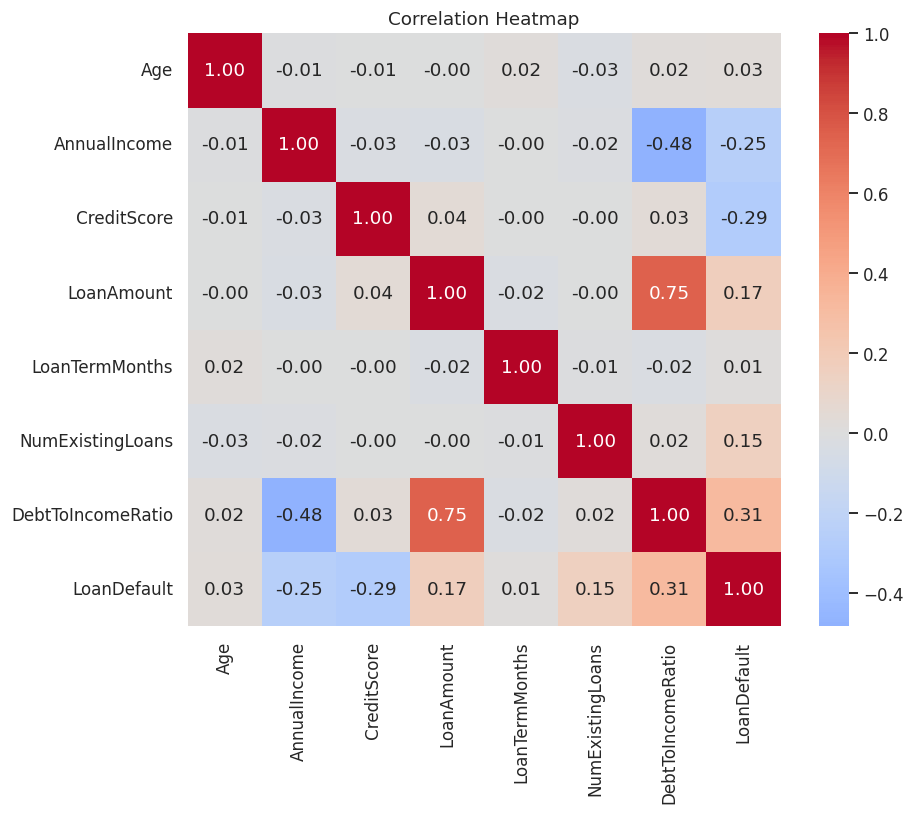

LoanDefault          1.000000
DebtToIncomeRatio    0.314155
LoanAmount           0.169898
NumExistingLoans     0.148474
Age                  0.028248
LoanTermMonths       0.011763
AnnualIncome        -0.251052
CreditScore         -0.285303
Name: LoanDefault, dtype: float64

In [6]:
numeric_cols = ["Age", "AnnualIncome", "CreditScore", "LoanAmount",
                 "LoanTermMonths", "NumExistingLoans", "DebtToIncomeRatio"]
corr = df[numeric_cols + ["LoanDefault"]].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap")
plt.show()

corr["LoanDefault"].sort_values(ascending=False)

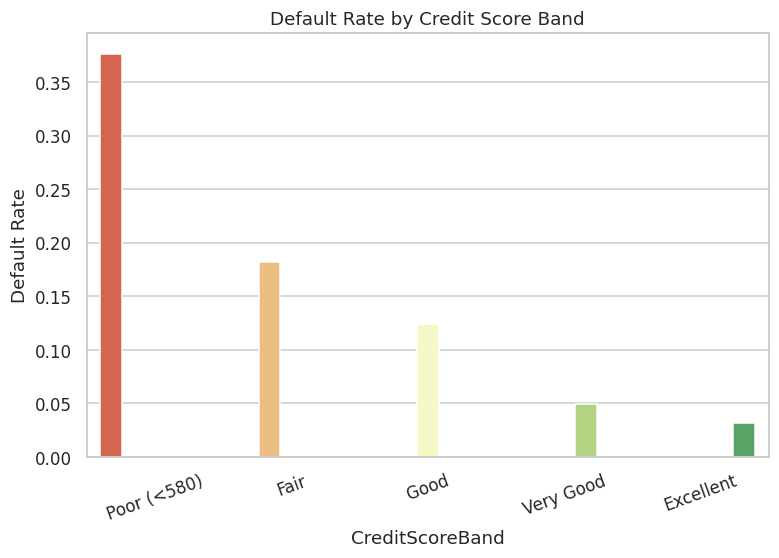

CreditScoreBand
Poor (<580)    0.377
Fair           0.182
Good           0.124
Very Good      0.049
Excellent      0.032
Name: LoanDefault, dtype: float64

In [7]:
df["CreditScoreBand"] = pd.cut(df["CreditScore"], bins=[300, 580, 670, 740, 800, 850],
                                labels=["Poor (<580)", "Fair", "Good", "Very Good", "Excellent"])
rate_by_band = df.groupby("CreditScoreBand", observed=True)["LoanDefault"].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=rate_by_band.index, y=rate_by_band.values, hue=rate_by_band.index, palette="RdYlGn", legend=False)
plt.title("Default Rate by Credit Score Band")
plt.ylabel("Default Rate")
plt.xticks(rotation=20)
plt.show()

rate_by_band.round(3)

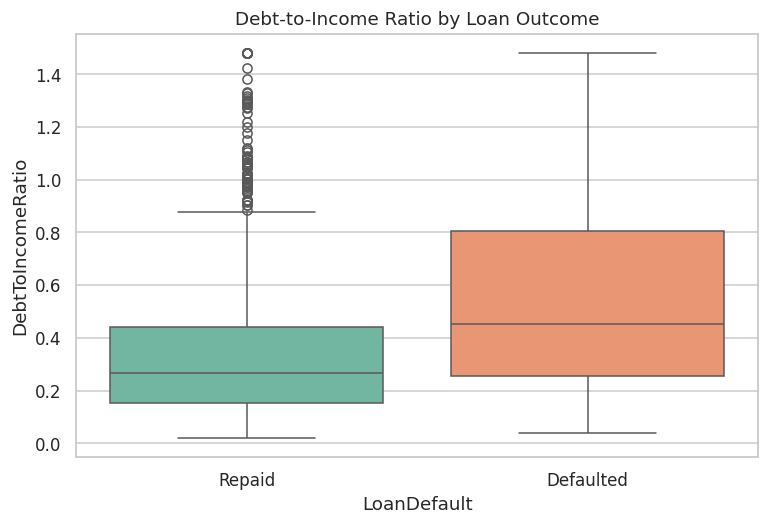

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="LoanDefault", y="DebtToIncomeRatio", hue="LoanDefault", palette="Set2", legend=False)
plt.xticks([0,1], ["Repaid", "Defaulted"])
plt.title("Debt-to-Income Ratio by Loan Outcome")
plt.show()

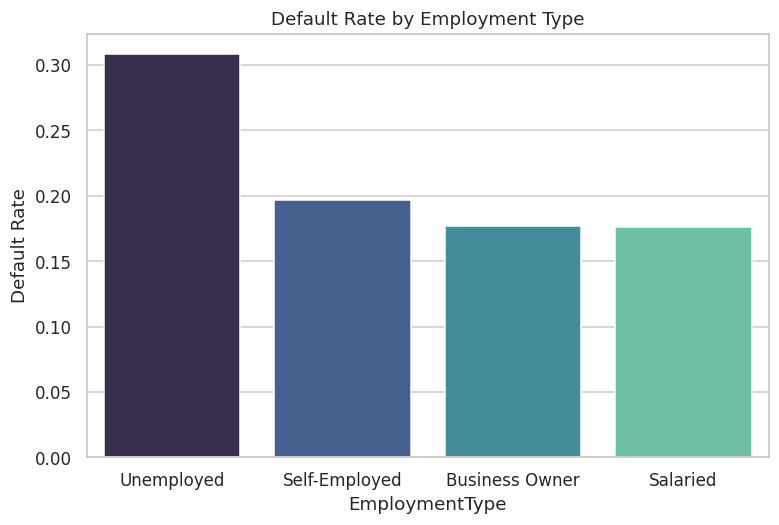

EmploymentType
Unemployed        0.308
Self-Employed     0.197
Business Owner    0.177
Salaried          0.176
Name: LoanDefault, dtype: float64

In [9]:
rate_by_emp = df.groupby("EmploymentType")["LoanDefault"].mean().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=rate_by_emp.index, y=rate_by_emp.values, hue=rate_by_emp.index, palette="mako", legend=False)
plt.title("Default Rate by Employment Type")
plt.ylabel("Default Rate")
plt.show()

rate_by_emp.round(3)

## 4. Build Predictive Models

In [10]:
cat_cols = ["EmploymentType", "HomeOwnership", "MaritalStatus", "LoanPurpose"]
df_model = df.copy()
for col in cat_cols:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

feature_cols = ["Age", "AnnualIncome", "EmploymentType", "CreditScore", "LoanAmount",
                 "LoanTermMonths", "NumExistingLoans", "HomeOwnership", "MaritalStatus",
                 "LoanPurpose", "DebtToIncomeRatio"]
X = df_model[feature_cols]
y = df_model["LoanDefault"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1600, 11) Test: (400, 11)


In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, class_weight="balanced")
}

results = {}
predictions = {}
for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    }
    predictions[name] = {"y_pred": y_pred, "y_proba": y_proba}

results_df = pd.DataFrame(results).T.round(4)
results_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.7525,0.4234,0.7436,0.5395,0.8549
Random Forest,0.8475,0.6164,0.5769,0.5960,0.8342


## 5. Evaluate: Confusion Matrices & ROC Curves

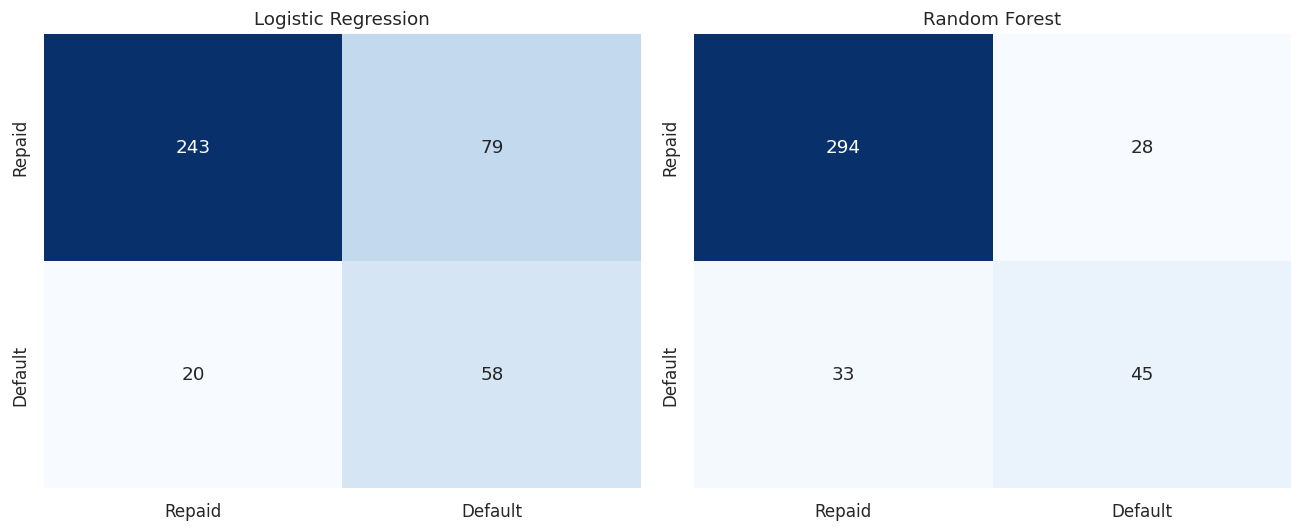

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Repaid","Default"], yticklabels=["Repaid","Default"])
    ax.set_title(name)
plt.tight_layout()
plt.show()

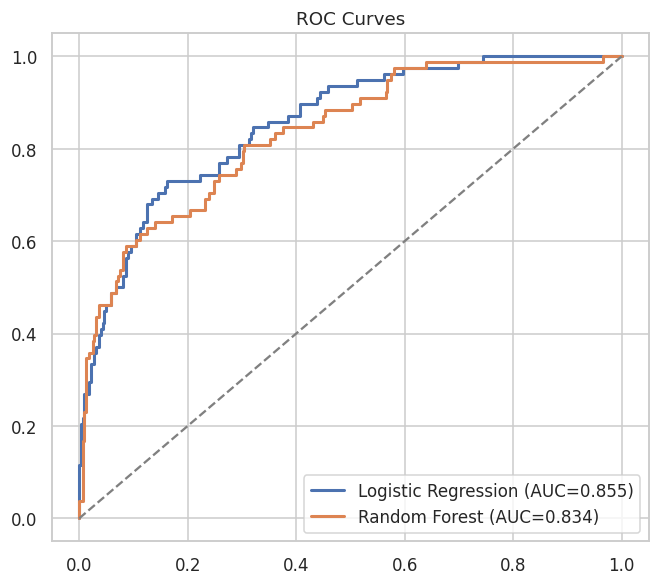

In [13]:
plt.figure(figsize=(7,6))
for name, preds in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, preds["y_proba"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})", linewidth=2)
plt.plot([0,1],[0,1],"--", color="gray")
plt.title("ROC Curves")
plt.legend()
plt.show()

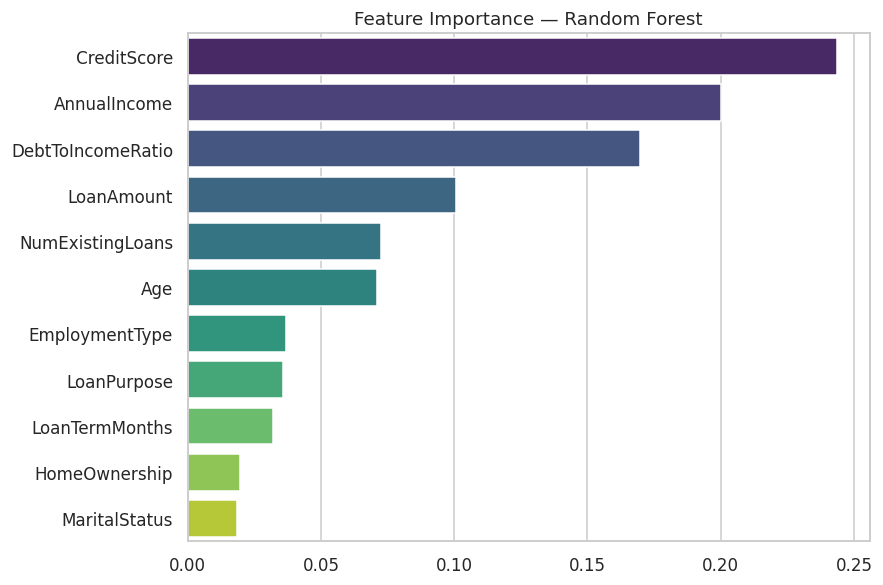

In [14]:
rf = models["Random Forest"]
imp = sorted(zip(feature_cols, rf.feature_importances_), key=lambda x: x[1], reverse=True)
names, vals = zip(*imp)
plt.figure(figsize=(8,6))
sns.barplot(x=list(vals), y=list(names), hue=list(names), palette="viridis", legend=False)
plt.title("Feature Importance — Random Forest")
plt.show()

In [15]:
print(classification_report(y_test, predictions["Random Forest"]["y_pred"]))

              precision    recall  f1-score   support

           0       0.90      0.91      0.91       322
           1       0.62      0.58      0.60        78

    accuracy                           0.85       400
   macro avg       0.76      0.74      0.75       400
weighted avg       0.84      0.85      0.85       400



## 6. Key Findings & Recommendations

- **Credit score and debt-to-income ratio are the two strongest predictors of default**,
  confirmed both by correlation analysis and Random Forest feature importance.
- Applicants in the **"Poor" credit band (<580) default at ~38%**, compared to just
  ~3% for "Excellent" credit — a more than 10x difference in risk.
- **Higher debt-to-income ratio strongly separates defaulters from non-defaulters** — median
  DTI for defaulters is roughly double that of applicants who repaid.
- Both models achieve **ROC AUC ≈ 0.83–0.85**, indicating strong discriminative power between
  likely defaulters and likely repayers.
- **Random Forest gives higher precision (0.62)**, useful for minimizing false declines,
  while **Logistic Regression gives higher recall (0.74)**, useful for catching more true
  defaulters — the right choice depends on whether the business prioritizes approval rate
  or risk minimization.

### Business Recommendation
Use **credit score band and debt-to-income ratio as primary underwriting signals**, with the
Random Forest model score as a secondary risk-ranking tool to flag applications for manual
review rather than automatic approval/decline — balancing default risk against not over-rejecting
creditworthy applicants.
